In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import spacy
from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("final_recipes_dataset.csv")

In [3]:
data = data .drop(columns=["Photo"])
data

,NormTitle,achiote,acorn,active dry yeast,adobo season,adzuki bean,aekjeot,agushi seed,ajilimo,ajinomoto seasoning,...,yerba mate,yoghurt,yogurt,yolk,yorkshire pudding,yukon gold potato,zheera,ziti,zucchini,zuckerhut
0,Cake,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Nice cup of tea,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Corn flour with palm oil,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Corn flour with palm oil,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Three stews,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,Zucchini pie,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
793,Cucumber soup,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
794,Zuppa Toscana,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
795,Sautéed onion roast,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Tokenization using spacy library

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "tagger", "lemmatizer"])

def tokenize(text: str):
    doc = nlp(str(text).lower())
    toks = [t.text for t in doc if (not t.is_space) and (not t.is_punct)]
    toks = [t for t in toks if len(t) > 1]
    return toks

## Train-test-split using scikit learn

In [5]:
data = data.copy()
data["NormTitle"] = data["NormTitle"].fillna("")

candidate_cols = [c for c in data.columns if c != "NormTitle"]

label_cols = []
for c in candidate_cols:
    s = pd.to_numeric(data[c], errors="coerce")
    if s.isna().mean() > 0.01:
        continue
    vals = set(s.dropna().unique().tolist())
    if vals.issubset({0, 1}):
        label_cols.append(c)

data[label_cols] = data[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32)

train_df, temp_df = train_test_split(data, test_size=0.2, random_state=123, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=123, shuffle=True)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("n_labels =", len(label_cols))
print("train/val/test:", train_df.shape, val_df.shape, test_df.shape)
print("example labels:", label_cols[:20])

n_labels = 1138
train/val/test: (637, 1248) (80, 1248) (80, 1248)
example labels: ['achiote', 'acorn', 'active dry yeast', 'adobo season', 'adzuki bean', 'aekjeot', 'agushi seed', 'ajilimo', 'ajinomoto seasoning', 'akamu', 'ale', 'allspice', 'almond butter', 'almond extract', 'almond flavor', 'almond flour', 'almond meal', 'almond oil', 'almond powder', 'alubosa']


## Encoding using tokenizer

In [6]:
from collections import Counter

counter = Counter()
for t in train_df["NormTitle"]:
    toks = tokenize(t)
    bigrams = [toks[i] + "_" + toks[i+1] for i in range(len(toks)-1)]
    counter.update(toks + bigrams)

vocab = {"<pad>": 0, "<unk>": 1}

for tok, freq in counter.items():
    if freq >= 1 and tok not in vocab:
        vocab[tok] = len(vocab)

def encode(text: str):
    toks = tokenize(text)
    bigrams = [toks[i] + "_" + toks[i+1] for i in range(len(toks)-1)]
    toks = toks + bigrams
    if not toks:
        return [vocab["<unk>"]]
    return [vocab.get(tok, vocab["<unk>"]) for tok in toks]

## Embedding + collate if title has more than one word therefore several tokens

In [7]:
class MultiLabelTextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label_cols):
        self.texts = df["NormTitle"].tolist()
        self.Y = df[label_cols].astype(np.float32).values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        ids = torch.tensor(encode(self.texts[i]), dtype=torch.long)
        y   = torch.tensor(self.Y[i], dtype=torch.float32)
        return ids, y

def collate_embeddingbag(batch):
    token_lists, ys = zip(*batch)
    lengths = [len(x) for x in token_lists]
    flat_tokens = torch.cat(token_lists, dim=0)
    offsets = torch.tensor([0] + list(np.cumsum(lengths)[:-1]), dtype=torch.long)
    Yb = torch.stack(ys, dim=0)
    return flat_tokens, offsets, Yb

train_ds = MultiLabelTextDataset(train_df, label_cols)
val_ds   = MultiLabelTextDataset(val_df, label_cols)
test_ds  = MultiLabelTextDataset(test_df, label_cols)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_embeddingbag)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_embeddingbag)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_embeddingbag)

## Neural network 

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [9]:
class FoodClassifier(nn.Module):
    def __init__(self, vocab_size, n_labels, embed_dim=128, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_labels),
        )

    def forward(self, tokens, offsets):
        embedded = self.embedding(tokens, offsets)
        output = self.net(embedded)
        return output

In [10]:
model = FoodClassifier(vocab_size=len(vocab), n_labels=len(label_cols)).to(device)

## Loss function (BCE loss with sigmoid)

In [11]:
train_Y = train_df[label_cols].values.astype(np.float32)

pos = train_Y.sum(axis=0)
neg = train_Y.shape[0] - pos

pos_weight = torch.tensor((neg + 1e-6) / (pos + 1e-6), dtype=torch.float32).to(device)
pos_weight = torch.clamp(pos_weight, max=20.0)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

## Metrics

In [12]:
@torch.no_grad()
def jaccard_from_logits(logits, y_true, threshold):
    probs = torch.sigmoid(logits)
    y_pred = (probs >= threshold).float()

    inter = (y_pred * y_true).sum(dim=1)
    union = ((y_pred + y_true) > 0).float().sum(dim=1)

    per_sample = inter / (union + 1e-9)
    return per_sample.mean().item()

@torch.no_grad()
def micro_jaccard_from_logits(logits, y_true, threshold):
    probs = torch.sigmoid(logits)
    y_pred = (probs >= threshold).float()

    inter = (y_pred * y_true).sum().item()
    union = ((y_pred + y_true) > 0).float().sum().item()

    return inter / (union + 1e-9)

@torch.no_grad()
def micro_f1_from_logits(logits, y_true, threshold):
    probs = torch.sigmoid(logits)
    y_pred = (probs >= threshold).float()

    tp = (y_pred * y_true).sum().item()
    fp = (y_pred * (1 - y_true)).sum().item()
    fn = ((1 - y_pred) * y_true).sum().item()

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    return f1, precision, recall

@torch.no_grad()
def precision_recall_at_k(logits, y_true, k):
    topk = torch.topk(logits, k=k, dim=1).indices
    y_true_bool = y_true.bool()

    p_list, r_list = [], []
    for i in range(logits.size(0)):
        pred_idx = topk[i]
        hit = y_true_bool[i, pred_idx].sum().item()
        true_cnt = y_true_bool[i].sum().item()
        p_list.append(hit / k)
        r_list.append(hit / (true_cnt + 1e-9))

    return float(np.mean(p_list)), float(np.mean(r_list))

## Training

In [13]:
optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-2)

train_loss_hist = []
val_loss_hist   = []
val_f1_hist     = []
val_p10_hist    = []
val_r10_hist    = []
val_jacc_hist = []

def run_one_epoch(loader, train):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_logits = []
    all_y      = []

    for flat_tokens, offsets, yb in tqdm(loader, disable=not train):
        flat_tokens = flat_tokens.to(device)
        offsets     = offsets.to(device)
        yb          = yb.to(device)

        logits = model(flat_tokens, offsets)
        loss = criterion(logits, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * yb.size(0)
        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    all_logits = torch.cat(all_logits, dim=0)
    all_y = torch.cat(all_y, dim=0)
    return avg_loss, all_logits, all_y

best_val_f1 = -1
best_state = None
N = 20

for epoch in range(N):
    tr_loss, _, _ = run_one_epoch(train_loader, train=True)
    va_loss, va_logits, va_y = run_one_epoch(val_loader, train=False)

    va_f1, _, _ = micro_f1_from_logits(va_logits, va_y, threshold=0.5)
    p10, r10 = precision_recall_at_k(va_logits, va_y, k=10)
    va_j = jaccard_from_logits(va_logits, va_y, threshold=0.5)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(va_loss)
    val_f1_hist.append(va_f1)
    val_p10_hist.append(p10)
    val_r10_hist.append(r10)
    val_jacc_hist.append(va_j)

    print(f"Epoch {epoch+1:02d}/{N} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} | val micro-F1 {va_f1:.4f} | P@10 {p10:.4f} | R@10 {r10:.4f} | Jacc {va_j:.4f}")

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

100%|██████████| 10/10 [00:01<00:00,  6.68it/s]


Epoch 01/20 | train loss 0.5536 | val loss 0.3317 | val micro-F1 0.0531 | P@10 0.0575 | R@10 0.2079 | Jacc 0.0510


100%|██████████| 10/10 [00:01<00:00,  6.70it/s]


Epoch 02/20 | train loss 0.2598 | val loss 0.2365 | val micro-F1 0.0547 | P@10 0.0563 | R@10 0.1990 | Jacc 0.0422


100%|██████████| 10/10 [00:01<00:00,  6.98it/s]


...

Epoch 18/20 | train loss 0.0201 | val loss 0.3822 | val micro-F1 0.1340 | P@10 0.0613 | R@10 0.1774 | Jacc 0.0774


100%|██████████| 10/10 [00:01<00:00,  7.01it/s]


Epoch 19/20 | train loss 0.0181 | val loss 0.3938 | val micro-F1 0.1372 | P@10 0.0650 | R@10 0.1889 | Jacc 0.0844


100%|██████████| 10/10 [00:01<00:00,  7.09it/s]


Epoch 20/20 | train loss 0.0164 | val loss 0.4037 | val micro-F1 0.1338 | P@10 0.0638 | R@10 0.1754 | Jacc 0.0816


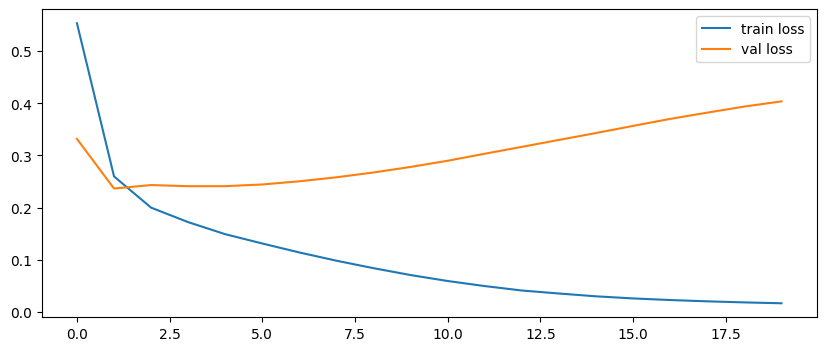

In [14]:
plt.figure(figsize=(10,4))
plt.plot(train_loss_hist, label="train loss")
plt.plot(val_loss_hist, label="val loss")
plt.legend()
plt.show()

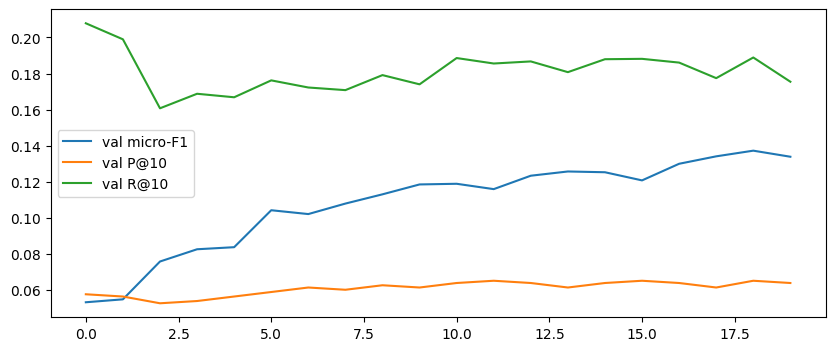

In [15]:
plt.figure(figsize=(10,4))
plt.plot(val_f1_hist, label="val micro-F1")
plt.plot(val_p10_hist, label="val P@10")
plt.plot(val_r10_hist, label="val R@10")
plt.legend()
plt.show()

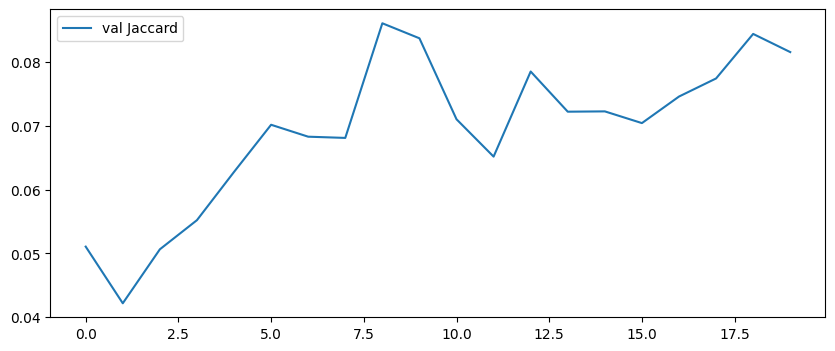

In [16]:
plt.figure(figsize=(10,4))
plt.plot(val_jacc_hist, label="val Jaccard")
plt.legend()
plt.show()

## Test

In [17]:
model.load_state_dict(best_state)

te_loss, te_logits, te_y = run_one_epoch(test_loader, train=False)
te_f1, te_p, te_r = micro_f1_from_logits(te_logits, te_y, threshold=0.5)
p10, r10 = precision_recall_at_k(te_logits, te_y, k=10)

print("=== TEST ===")
print(f"loss {te_loss:.4f} | micro-F1 {te_f1:.4f} | precision {te_p:.4f} | recall {te_r:.4f} | P@10 {p10:.4f} | R@10 {r10:.4f} | Jacc {va_j:.4f}")

=== TEST ===
loss 0.4773 | micro-F1 0.0789 | precision 0.1105 | recall 0.0614 | P@10 0.0475 | R@10 0.1079 | Jacc 0.0816


## Prediction

In [18]:
@torch.no_grad()
def predict_title(title: str, topk):
    model.eval()
    ids = torch.tensor(encode(title), dtype=torch.long).to(device)
    offsets = torch.tensor([0], dtype=torch.long).to(device)
    logits = model(ids, offsets).detach().cpu().squeeze(0)
    top_idx = torch.topk(logits, k=topk).indices.numpy().tolist()
    top_labels = [label_cols[i] for i in top_idx]
    top_scores = torch.sigmoid(logits[top_idx]).numpy().tolist()
    return list(zip(top_labels, top_scores))

predict_title("pasta", topk=10)

[('vanilla', 0.47018393874168396),
 ('turmeric', 0.2561570107936859),
 ('white wine', 0.17925554513931274),
 ('mushroom', 0.16073210537433624),
 ('rice', 0.1527060717344284),
 ('wheat flour', 0.13604424893856049),
 ('lentil', 0.12072998285293579),
 ('shrimp', 0.11210031062364578),
 ('oregano', 0.11002210527658463),
 ('yeast', 0.08772789686918259)]

In [19]:
predict_title("spaghetti", topk=10)

[('spaghetti', 0.9998792409896851),
 ('pasta sauce', 0.9840100407600403),
 ('tomato paste', 0.9101067781448364),
 ('plum tomato', 0.6560632586479187),
 ('ham', 0.5650014877319336),
 ('mayonnaise', 0.3717252016067505),
 ('tomato pur e', 0.3666778802871704),
 ('bay leaf', 0.3561764061450958),
 ('beef', 0.2962905168533325),
 ('banana ketchup', 0.26025062799453735)]